# 🛍️ Customer Segmentation — EDA & Clustering

**Objective:** Explore customer characteristics and apply K-Means clustering to segment customers for targeted marketing strategies.

**Dataset:** 300 synthetic customers with features: `age`, `annual_income`, `spending_score`, `purchase_frequency`.

**Notebook structure:**
1. Setup & Imports
2. Data Generation
3. Data Overview
4. Feature Distributions
5. Pairplot Analysis
6. K-Means: Optimal Clusters (Elbow Method)
7. K-Means Clustering & Visualization
8. Insights & Conclusions

In [1]:
# 1. Setup & Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

print("Setup complete.")

Setup complete.


In [2]:
# 2. Data Generation (synthetic, reproducible)
def generate_customer_data(n: int = 300, seed: int = 42) -> pd.DataFrame:
    """Generate a synthetic customer dataset with 3 latent segments."""
    rng = np.random.default_rng(seed)

    cluster_centers = {
        0: {"age": 25, "income": 35, "spend": 20, "freq": 5},
        1: {"age": 45, "income": 80, "spend": 70, "freq": 15},
        2: {"age": 35, "income": 50, "spend": 40, "freq": 8},
    }

    rows = []
    for _ in range(n):
        c = rng.choice([0, 1, 2])
        center = cluster_centers[c]
        rows.append({
            "age": int(np.clip(rng.normal(center["age"], 5), 18, 70)),
            "annual_income": float(np.clip(rng.normal(center["income"], 10), 15, 150)),
            "spending_score": float(np.clip(rng.normal(center["spend"], 10), 1, 100)),
            "purchase_frequency": int(np.clip(rng.normal(center["freq"], 2), 1, 30)),
        })
    return pd.DataFrame(rows)


df = generate_customer_data(300)
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(10)

Dataset shape: 300 rows × 4 columns


,age,annual_income,spending_score,purchase_frequency
0,19,42.504512,29.405647,1
1,28,51.278404,36.837574,7
2,39,57.777919,40.660307,10
3,47,71.407075,73.687508,13
4,34,48.151376,33.190705,10
5,34,45.716722,36.478664,9
6,47,84.308210,91.416476,14
7,22,26.862273,26.159794,7
8,40,71.755188,76.505928,16
9,27,28.344903,22.321613,5


In [3]:
# 3. Data Overview
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Statistical Summary ===")
df.describe().T

print("\n=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values found. ✅")

=== Data Types ===
age                     int64
annual_income         float64
spending_score        float64
purchase_frequency      int64
dtype: object

=== Statistical Summary ===

=== Missing Values ===
No missing values found. ✅


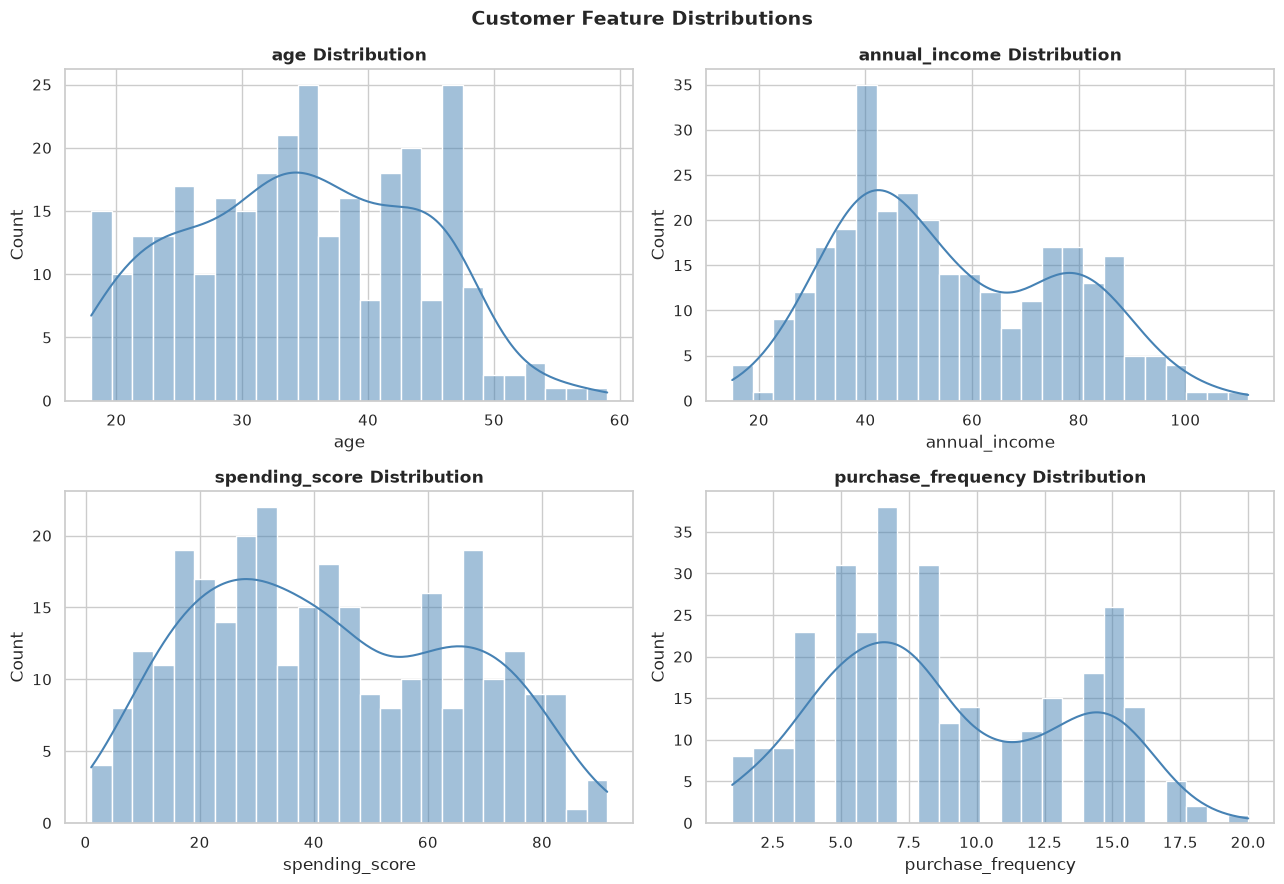

In [4]:
# 4. Feature Distributions
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flatten(), df.columns):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue", bins=25)
    ax.set_title(f"{col} Distribution", fontweight="bold")
plt.suptitle("Customer Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

/run/media/bugs/Data/Febriyansyah-Other/Project/github-repo/.venv/lib/python3.14/site-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/run/media/bugs/Data/Febriyansyah-Other/Project/github-repo/.venv/lib/python3.14/site-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/run/media/bugs/Data/Febriyansyah-Other/Project/github-repo/.venv/lib/python3.14/site-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/run/media/bugs/Data/Febriyansyah-Other/Project/github-repo/.venv/lib/python3.14/site-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/run/media/bugs/Data/Febriyansyah-Other/Project/github-repo/.venv/lib/python3.14

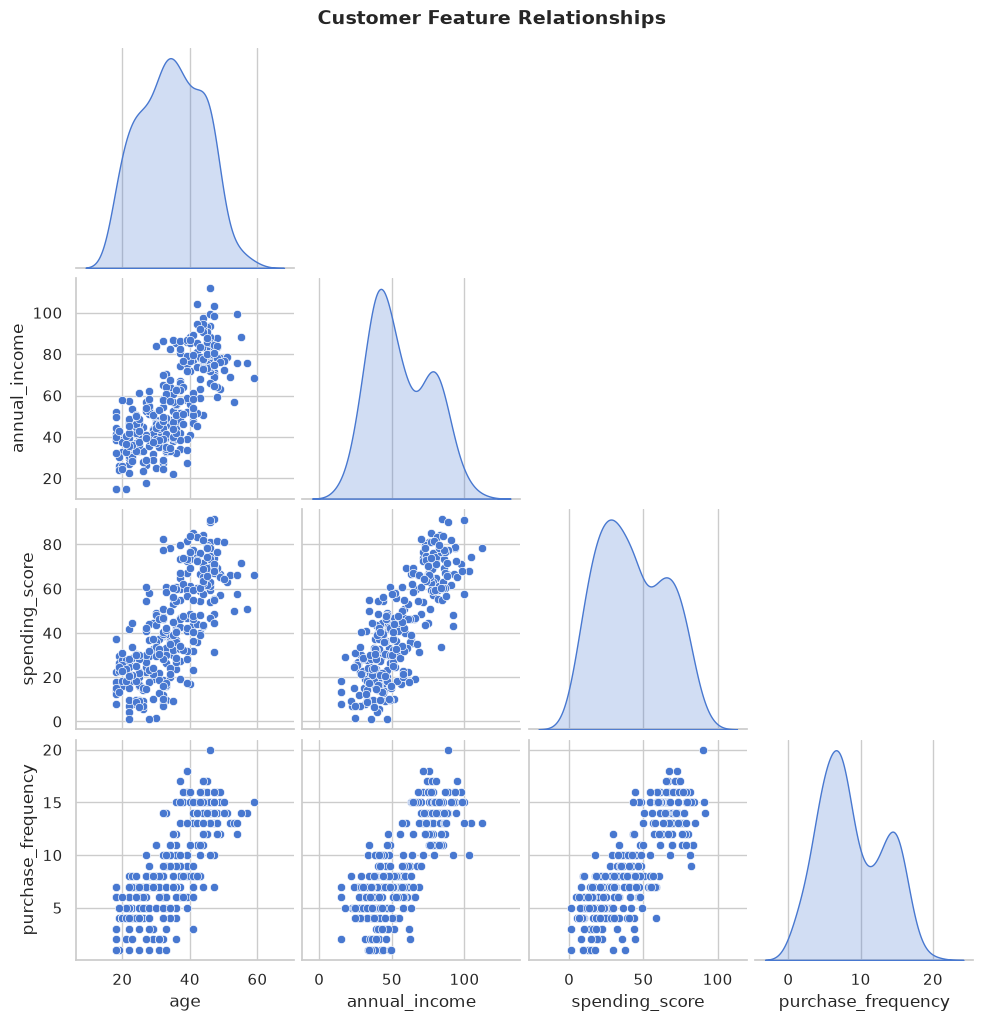

In [ ]:
# 5. Pairplot Analysis
sns.pairplot(df, diag_kind="kde", corner=True)
plt.suptitle("Customer Feature Relationships", y=1.02, fontsize=14, fontweight="bold")
plt.show()

In [ ]:
# 6. K-Means: Optimal Number of Clusters (Elbow Method)
# Standardize features (important for distance-based algorithms)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

inertias = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, marker="o", color="steelblue", linewidth=2)
plt.title("Elbow Method for Optimal K", fontsize=14, fontweight="bold")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 7. K-Means Clustering (K=3 based on elbow & data generation)
K = 3
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

print("=== Cluster Sizes ===")
print(df["cluster"].value_counts().sort_index())

print("\n=== Cluster Profiles (mean) ===")
print(df.groupby("cluster").mean().round(2))

In [ ]:
# 8. Cluster Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Income vs Spending Score
sns.scatterplot(data=df, x="annual_income", y="spending_score", hue="cluster",
                palette="Set2", s=60, alpha=0.8, ax=axes[0])
axes[0].set_title("Clusters: Income vs Spending Score", fontweight="bold")

# Age vs Purchase Frequency
sns.scatterplot(data=df, x="age", y="purchase_frequency", hue="cluster",
                palette="Set2", s=60, alpha=0.8, ax=axes[1])
axes[1].set_title("Clusters: Age vs Purchase Frequency", fontweight="bold")

plt.tight_layout()
plt.show()

## 📌 Insights & Conclusions

1. **Three distinct customer segments** emerge from the data (confirmed by the elbow method at K=3).
2. **Segment profiles:**
   - **Cluster 0 — Young budget shoppers:** younger, lower income, lower spending.
   - **Cluster 1 — Affluent frequent buyers:** older, high income, high spending & frequency.
   - **Cluster 2 — Middle segment:** moderate income, spending, and frequency.
3. **Feature scaling is essential** for K-Means — features have very different scales (income in tens, frequency in single digits).
4. **Marketing implication:** tailor campaigns per segment — e.g., premium loyalty programs for Cluster 1, value promotions for Cluster 0.